## Imports das Bibliotecas

In [1]:
## Imports Geral
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import nltk
import numpy as np

# Import para Visualização de Dados
from wordcloud import WordCloud

# Extração de Texto
from nltk.corpus import stopwords

# Importações de Metrica
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Preprocessamento
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# Modelos
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

import warnings

# Suprimir todos os warnings
warnings.filterwarnings("ignore")

# DESENVOLVER O MODELO SEM VIES 

# Analise dos dados

In [2]:
df = pd.read_csv("cor_da_justica.csv")
remover_colunas = ["Unnamed: 0", "uris.uriAutores", "uris.uriPropPrincipal",
                   "uris.uriUltimoRelator", "foto", "cpf", ]
df = df.drop(columns=remover_colunas)
df = df.dropna(subset=["ementa"])
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10790 entries, 0 to 11736
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   ementa                 10790 non-null  object
 1   ementaDetalhada        491 non-null    object
 2   ano                    10790 non-null  int64 
 3   keywords               5071 non-null   object
 4   nome                   10790 non-null  object
 5   sexo                   10790 non-null  object
 6   nascimento             10790 non-null  object
 7   local_nascimento       10790 non-null  object
 8   escolaridade           10531 non-null  object
 9   uris.uriPartido        10790 non-null  object
 10  ementa_principal       10790 non-null  object
 11  situacao               2068 non-null   object
 12  tipo                   2242 non-null   object
 13  keywords_principal     2219 non-null   object
 14  nome_partido           10790 non-null  object
 15  sigla_partido          1

In [3]:
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementaDetalhada"] if x["ementaDetalhada"] == str(x["ementaDetalhada"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementa_principal"] if x["ementa_principal"] != str("vazio") else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords"] if x["keywords"] == str(x["keywords"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords_principal"] if x["keywords_principal"] == str(x["keywords_principal"]) else x["ementa"] , axis=1)

In [4]:
df = df.drop(columns=["ementaDetalhada", "ementa_principal", 'keywords', 'keywords_principal'])

In [5]:
df["situacao"].loc[(df["situacao"] == "Aguardando Designação de Relator(a)" ) | (df["situacao"] == "Aguardando Parecer") | (df["situacao"] == "Aguardando Encaminhamento") | (df["situacao"] == "Aguardando Definição Encaminhamento") | (df["situacao"] == "Aguardando Recurso") | (df["situacao"] == "Aguardando Despacho de Arquivamento ") | (df["situacao"] == "Aguardando Deliberação")  | (df["situacao"] == "Aguardando Designação - Aguardando Devolução de Relator(a) que deixou de ser Membro") | (df["situacao"] == "Aguardando Análise de Parecer") | (df["situacao"] == "Arquivada") ] = "AGUARDANDO"
df["situacao"].loc[(df["situacao"] == "Tramitando em Conjunto" ) | (df["situacao"] == "Pronta para Pauta")] = "TRAMITANDO"
df["situacao"] = df["situacao"].fillna("RECUSADO")

In [6]:
df = df.drop(df[(df['cor'] == "#NE") | (
    df["cor"] == "#NE#") | (df["cor"] == "NÃO DIVULGÁVEL")].index).reset_index(drop=True)

# df["cor"].loc[(df["cor"] == "AMARELA") | (
#     df["cor"] == "NÃO DIVULGÁVEL") | (df["cor"] == "INDÍGENA") | (df["cor"] == "PARDA") | (df["cor"] == "PRETA")] = "OUTROS"

In [7]:
df['cor'].value_counts()

cor
BRANCA      3421
PARDA        988
PRETA        220
AMARELA      103
INDÍGENA      86
Name: count, dtype: int64

In [8]:

## MODELOS SEM VIES

#Outros 100
#Brancos 100

#Gerar um classificar aleátorio / classificador sem viés tem que dar proximo a 50% de acurácia
# E macro F1 fica pior que 50%

#y_true = dados normais
#y_pred = se o valor for maior que 0.7 

#  f1_score(y_true, y_pred, average='macro')

branca = df["cor"].loc[(df["cor"] == 'BRANCA')].value_counts()
parda = df["cor"].loc[(df["cor"] == 'PARDA')].value_counts()
negra = df["cor"].loc[(df["cor"] == 'PRETA')].value_counts()
indigena = df["cor"].loc[(df["cor"] == 'INDÍGENA')].value_counts()
amarela = df["cor"].loc[(df["cor"] == 'AMARELA')].value_counts()

prob_brancos = (branca[0]/len(df["cor"]))
prob_pardas = (parda[0]/len(df["cor"]))
prob_negra = (negra[0]/len(df["cor"]))
prob_indigena = (indigena[0]/len(df["cor"]))
prob_amarela = (amarela[0]/len(df["cor"]))


y_prob = {'brancos': prob_brancos, 'pardas': prob_pardas, 'negra': prob_negra, 'indigena': prob_indigena, 'amarela': prob_amarela}


###obs: Aplicar para todos os modelos

In [9]:
y_prob

{'brancos': 0.7100456621004566,
 'pardas': 0.20506434205064342,
 'negra': 0.045662100456621,
 'indigena': 0.0178497301784973,
 'amarela': 0.021378165213781653}

In [10]:
df["cor"]

0       BRANCA
1        PARDA
2       BRANCA
3       BRANCA
4       BRANCA
         ...  
4813     PARDA
4814    BRANCA
4815    BRANCA
4816    BRANCA
4817    BRANCA
Name: cor, Length: 4818, dtype: object

In [11]:
df['cor'].value_counts()

cor
BRANCA      3421
PARDA        988
PRETA        220
AMARELA      103
INDÍGENA      86
Name: count, dtype: int64

In [12]:
cor = df["cor"].value_counts().reset_index()
cor["cor"].unique()
cor

,cor,count
0,BRANCA,3421
1,PARDA,988
2,PRETA,220
3,AMARELA,103
4,INDÍGENA,86


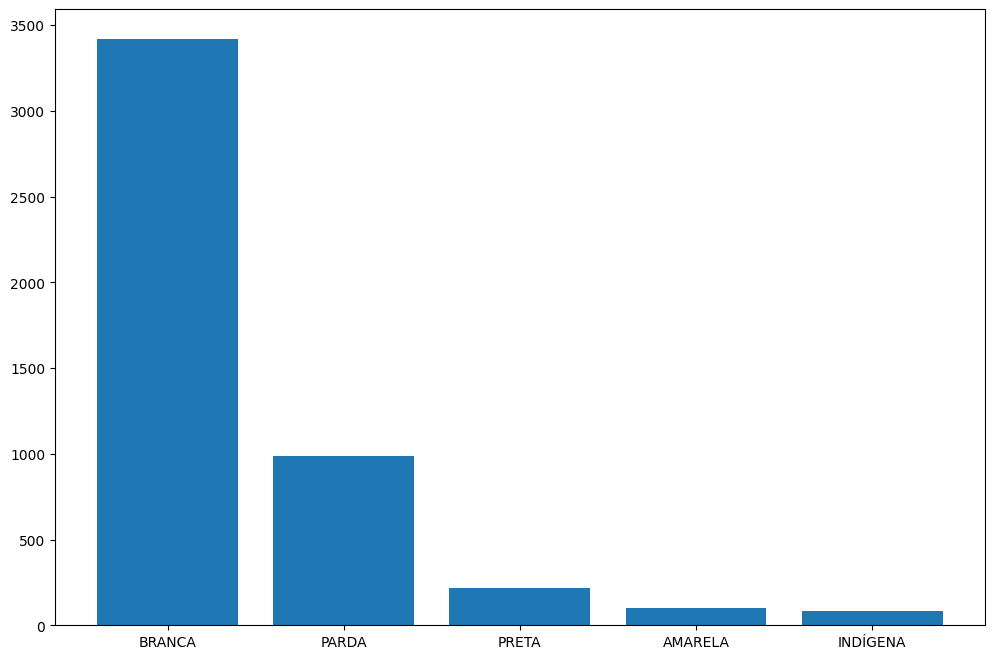

In [13]:
fx, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.bar(cor["cor"], height=cor["count"])
plt.show()

In [14]:
df["ementa"].dropna().count()

4818

## Bag Of Words

In [15]:
# nltk.download('stopwords')

In [16]:
df = df.dropna(subset=["ementa"]).reset_index(drop=True)

In [17]:
tf_idf = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
X = tf_idf.fit_transform(df["ementa"])
vocab = tf_idf.get_feature_names_out()
vocab = ' '.join(vocab)


## WORD CLOUD

In [18]:
le = LabelEncoder()

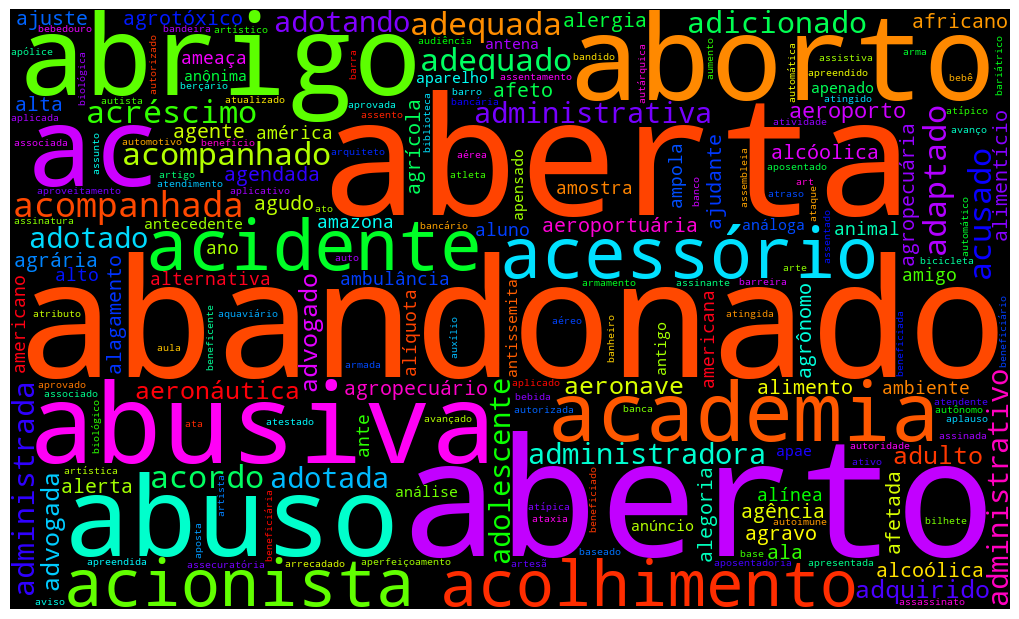

In [19]:
# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    colormap='gist_rainbow',
    min_font_size=10).generate(vocab)

plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

In [20]:
df_brancos = df[df["cor"] == "BRANCA"]
df_pardas  = df[df["cor"] == "PARDA"]
df_indigenas  = df[df["cor"] == "INDÍGENA"]
df_pretas  = df[df["cor"] == "PRETA"]
df_amarelas  = df[df["cor"] == "AMARELA"]



tf_idf_brancos = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
tf_idf_pardas = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )


y_brancos = le.fit_transform(df_brancos["situacao"])
y_pardas = le.fit_transform(df_pardas["situacao"])
y_indigena = le.fit_transform(df_indigenas["situacao"])
y_preta = le.fit_transform(df_pretas["situacao"])
y_amarela = le.fit_transform(df_amarelas["situacao"])

In [21]:
X_brancos = tf_idf_brancos.fit_transform(df_brancos["ementa"])
vocab_brancos = tf_idf_brancos.get_feature_names_out()
vocab_brancos = ' '.join(vocab_brancos)


In [22]:
vocab_brancos

'00 000 001 002 003 005 005766 009 01 010 013 014 015 016 019 02 02001 022 026 027 029 03 030 032 033 034 036 038 04 040 042 045 046 048 048410 05 052 06 069 07 070 072 074 076 078 079 08 080 087 09 090 095 096 098 099 10 100 1008 101 1010 10151 102 10273 10280 10284 103 10303 104 1045 1047 105 10583 106 1072 1074 1075 1077 108 10841 10975 11 110 1109 1111 112 1126 11260 115 1152 11530 116 1165 117 1175 119 1195 1198 11o 12 120 1205 121 122 1225 123 124 1241 1245 1249 125 126 127 128 129 1292 12965 13 130 131 132 133 134 135 1358 136 1366 1368 137 1371 1379 138 139 1394 13º 14 140 141 142 1425 143 144 145 1450 146 147 148 149 15 150 151 152 153 154 155 156 1560 1565 157 158 16 160 161 163 164 165 166 167 1671 168 17 171 172 173 174 175 176 1763 177 178 1784 1795 17ª 18 180 182 183 184 185 1853 186 187 1874 1875 188 189 19 1910 192 193 1937 1939 194 1940 1941 1942 1943 1945 1946 1948 195 1950 1955 1957 196 1960 1961 1962 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975 1976 1

In [23]:
X_pardas = tf_idf.fit_transform(df_pardas["ementa"])
vocab_pardas = tf_idf.get_feature_names_out()
vocab_pardas = ' '.join(vocab_pardas)


In [24]:
X_indigena = tf_idf.fit_transform(df_indigenas["ementa"])
vocab_indigena = tf_idf.get_feature_names_out()
vocab_indigena = ' '.join(vocab_indigena)


In [25]:
X_pretas = tf_idf.fit_transform(df_pretas["ementa"])
vocab_pretas = tf_idf.get_feature_names_out()
vocab_pretas = ' '.join(vocab_pretas)


In [26]:
X_amarelas = tf_idf.fit_transform(df_amarelas["ementa"])
vocab_amarelas = tf_idf.get_feature_names_out()
vocab_amarelas = ' '.join(vocab_amarelas)


## GRUPO 1: PESSOA DE COR DE PELE BRANCA

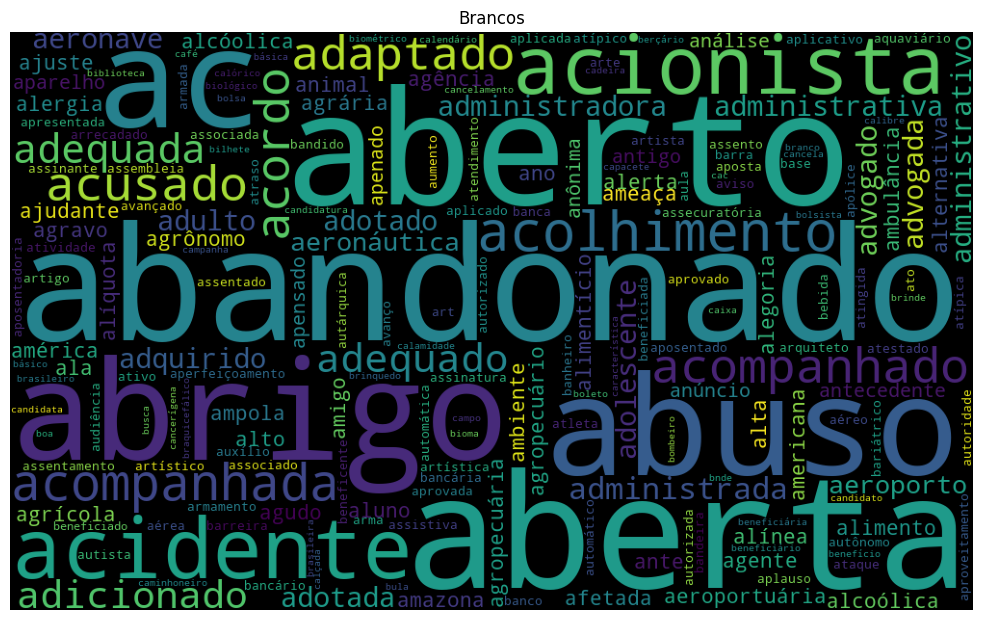

In [27]:

# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    min_font_size=10).generate(vocab_brancos)
plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.title('Brancos')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

## GRUPO 2: PESSOA DE COR DE PELE DIFERENTES 

# PARDAS

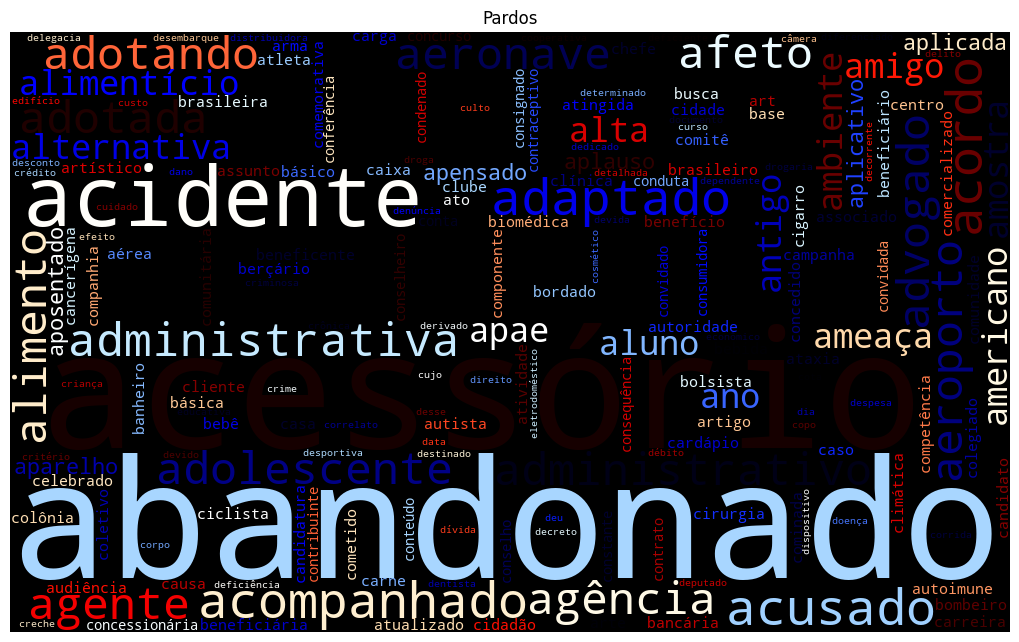

In [28]:

# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    colormap='flag_r',
    min_font_size=10).generate(vocab_pardas)
plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.title('Pardos')
plt.show()

# NEGRAS

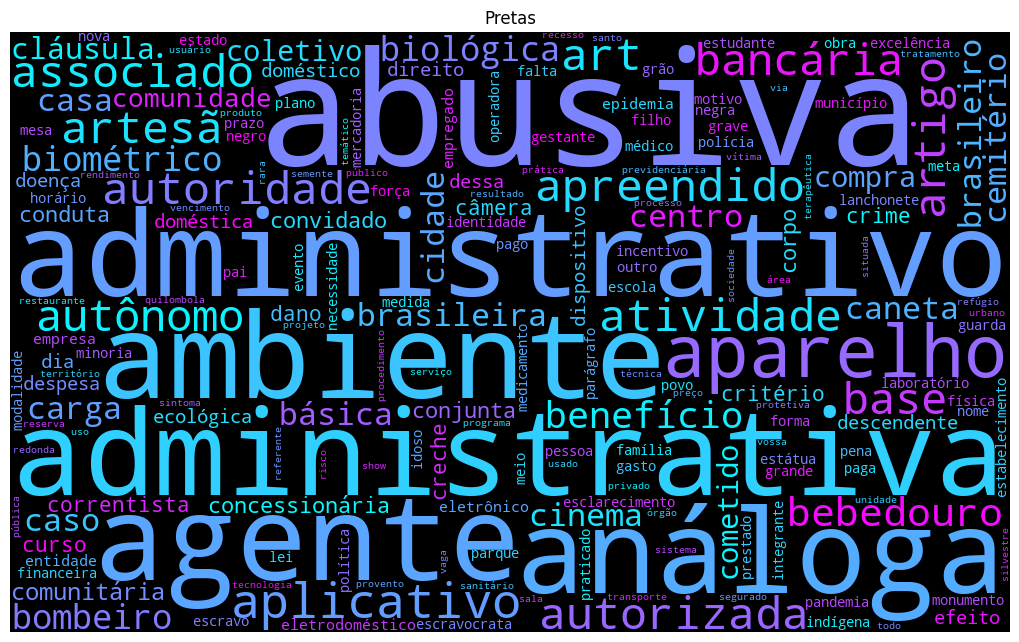

In [29]:

# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    colormap='cool',
    min_font_size=10).generate(vocab_pretas)
plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.title('Pretas')
plt.show()

# INDÍGENAS

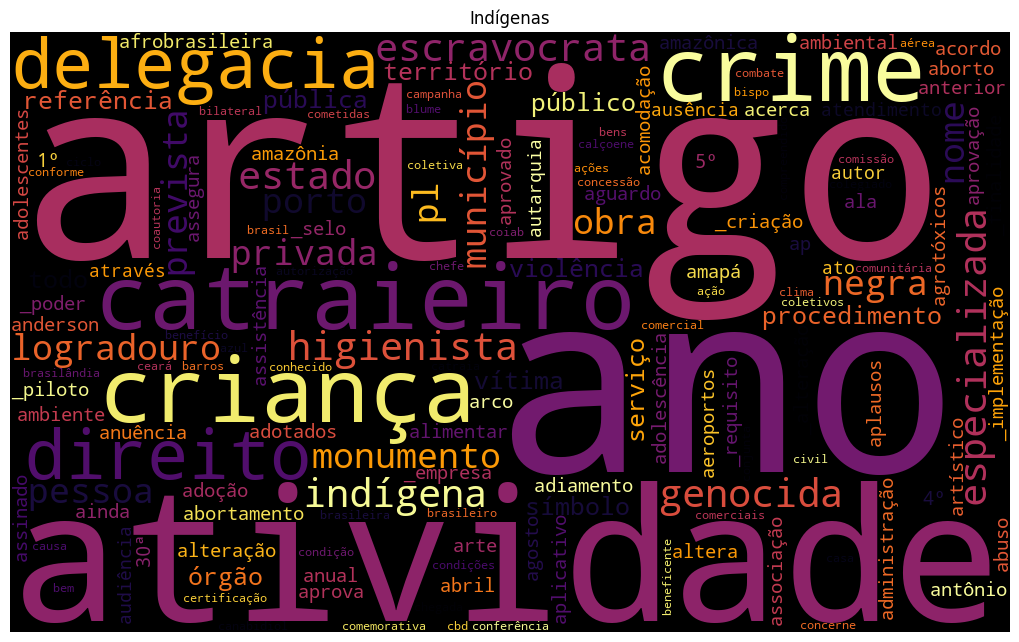

In [30]:

# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    colormap='inferno',
    min_font_size=10).generate(vocab_indigena)
plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.title('Indígenas')
plt.show()

# AMARELAS

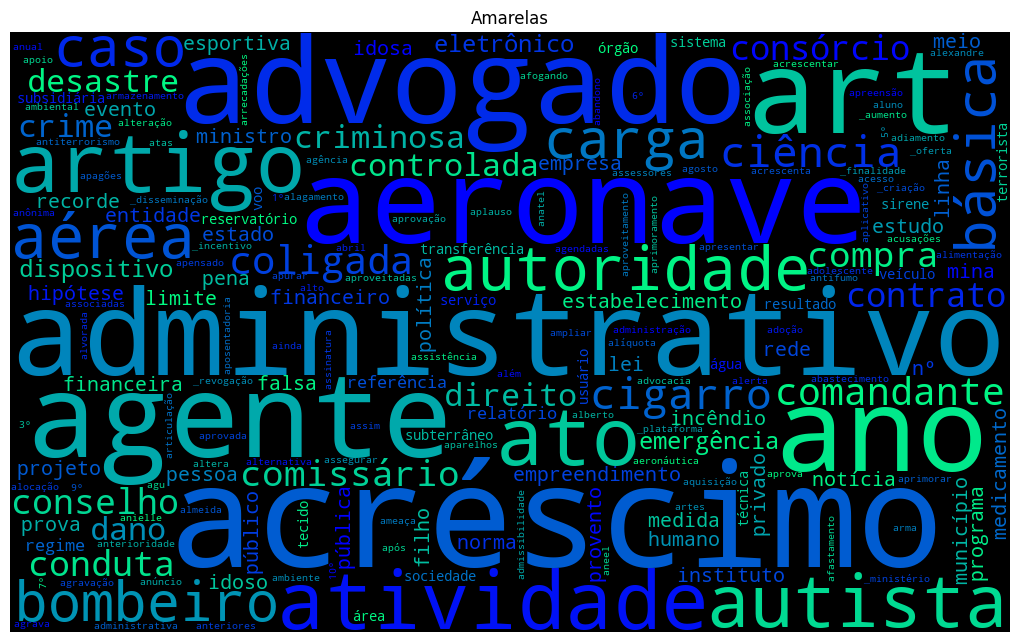

In [31]:

# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    colormap='winter',
    min_font_size=10).generate(vocab_amarelas)
plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.title('Amarelas')
plt.show()

# PCA

In [32]:
df['cor']

0       BRANCA
1        PARDA
2       BRANCA
3       BRANCA
4       BRANCA
         ...  
4813     PARDA
4814    BRANCA
4815    BRANCA
4816    BRANCA
4817    BRANCA
Name: cor, Length: 4818, dtype: object

In [33]:
le = LabelEncoder()

df["cor"] = le.fit_transform(df["cor"])
y = df["cor"]

In [34]:
y

0       1
1       3
2       1
3       1
4       1
       ..
4813    3
4814    1
4815    1
4816    1
4817    1
Name: cor, Length: 4818, dtype: int32

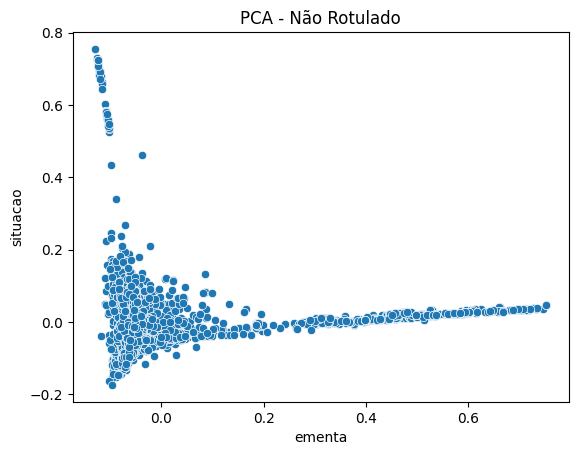

In [35]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())
df_pca = pd.DataFrame(data=X_pca, columns=['ementa', 'situacao'])
df_pca["target"] = df["cor"].reset_index(drop=True)


sns.scatterplot(x='ementa', y="situacao", data=df_pca)
plt.title('PCA - Não Rotulado')
plt.show()

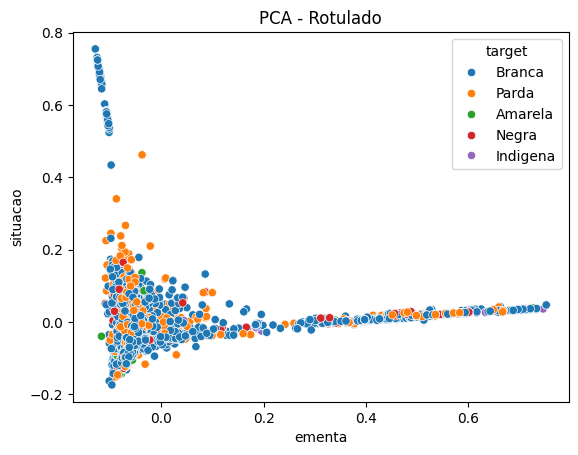

In [36]:
y_map = {0: 'Amarela', 1: 'Branca', 2: 'Indigena', 3: 'Parda', 4: 'Negra'}

df_pca["target"] = df["cor"].map(y_map)

sns.scatterplot(x='ementa', y="situacao", hue="target", data=df_pca)
plt.title('PCA - Rotulado')
plt.show()

## Treino do Modelo

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
from imblearn.over_sampling import SMOTE

# transform the dataset
oversample = SMOTE()
X_train, y_train = oversample.fit_resample(X_train, y_train)

In [39]:
## Funçao para Avaliação dos Modelos

def evaluation_parametrics(name, y_test, y_pred):
    cm_test = confusion_matrix(y_test, y_pred)
    
    t1 = ConfusionMatrixDisplay(cm_test, display_labels=[
                                "Amarela","Branca", "Indígena", 'Parda', 'Negra'])
    print("Classification Report for Data Test")
    print(classification_report(y_test, y_pred))
    t1.plot()

In [40]:
#K Fold

K = 5
kf = KFold(n_splits=K, shuffle=False) 

# Logistic Regression

In [41]:
model_LR = LogisticRegression(random_state=42, max_iter=1000, solver="liblinear", penalty="l2", C=3, tol=0.001)
cross_val_results = cross_val_score(model_LR, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_LR, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)


print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.19368235 0.20192734 0.21335306 0.22225357 0.21348054]
Media da Accuracy:  0.706923600608403
Media da MACRO F1:  0.20893937158742854
Desvio Padrão da MACRO F1:  0.009993158748792388


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.18      0.33      0.23        15
           1       0.81      0.79      0.80       698
           2       0.21      0.75      0.33        12
           3       0.47      0.41      0.44       200
           4       0.20      0.21      0.20        39

    accuracy                           0.68       964
   macro avg       0.37      0.50      0.40       964
weighted avg       0.69      0.68      0.68       964



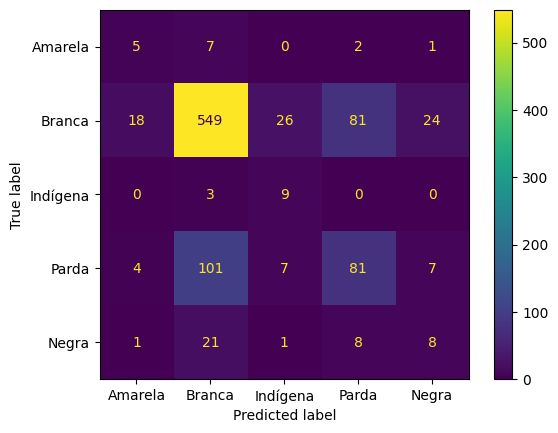

In [42]:
model_LR.fit(X_train, y_train)
y_pred = model_LR.predict(X_test)
evaluation_parametrics("Machine Learning - Logistic", y_test, y_pred)

# SGD Classifier

In [43]:
model_SGD = SGDClassifier(random_state=42, loss="squared_hinge", alpha=0.0001, learning_rate="constant", eta0=0.1, power_t=0.5, penalty="l2", tol=0.001, early_stopping=True, n_jobs=-1, class_weight="balanced")
cross_val_results = cross_val_score(model_SGD, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_SGD, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.24191221 0.30296783 0.38547037 0.29306601 0.29243516]
Media da Accuracy:  0.6575218779488372
Media da MACRO F1:  0.3031703153283823
Desvio Padrão da MACRO F1:  0.04635350192678497


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.09      0.13      0.11        15
           1       0.80      0.81      0.81       698
           2       0.24      0.75      0.37        12
           3       0.48      0.38      0.43       200
           4       0.17      0.18      0.17        39

    accuracy                           0.68       964
   macro avg       0.36      0.45      0.38       964
weighted avg       0.69      0.68      0.69       964



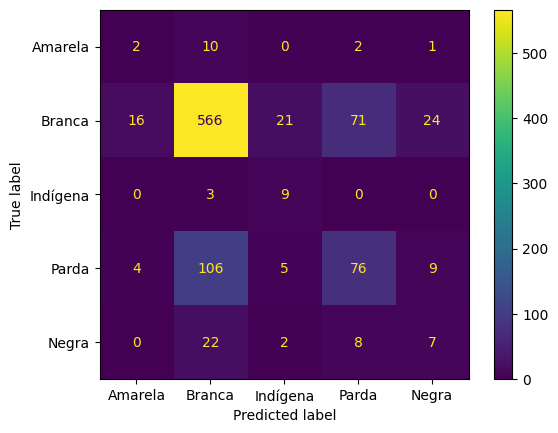

In [44]:
model_SGD.fit(X_train, y_train)
y_pred = model_SGD.predict(X_test)
evaluation_parametrics("Machine Learning - SGD", y_test, y_pred)

# K Neighbors Classifier

In [45]:
model_KNeighbors = KNeighborsClassifier(n_neighbors=5, weights="distance", algorithm="auto", leaf_size=50, p=2 )
cross_val_results = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="f1_macro", )
cross_val_results_accuracy = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.20612855 0.25969541 0.25083396 0.25697159 0.22267858]
Media da Accuracy:  0.6483895847606245
Media da MACRO F1:  0.23926161766766235
Desvio Padrão da MACRO F1:  0.021156085366959683


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.05      0.47      0.09        15
           1       0.88      0.24      0.38       698
           2       0.09      0.58      0.15        12
           3       0.31      0.57      0.40       200
           4       0.11      0.54      0.19        39

    accuracy                           0.33       964
   macro avg       0.29      0.48      0.24       964
weighted avg       0.71      0.33      0.37       964



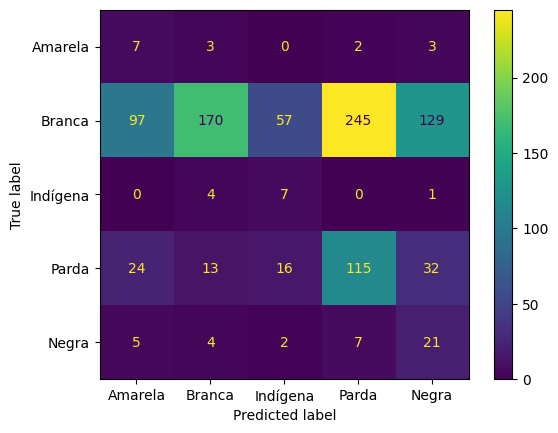

In [46]:
model_KNeighbors.fit(X_train, y_train)
y_pred = model_KNeighbors.predict(X_test)
evaluation_parametrics("Machine Learning - K Neighbors", y_test, y_pred)

# SVM (SUPPORT VECTOR MACHINE)

In [47]:
model_SVM = LinearSVC(random_state=42, loss='squared_hinge', max_iter=1000, penalty="l2", C=3, tol=0.0001, multi_class='ovr', dual=True, class_weight="balanced",  )
cross_val_results = cross_val_score(model_SVM, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_SVM, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.24005915 0.27259921 0.36322842 0.28700991 0.32218189]
Media da Accuracy:  0.6614726197093281
Media da MACRO F1:  0.29701571389719134
Desvio Padrão da MACRO F1:  0.04232680369963054


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.10      0.13      0.11        15
           1       0.80      0.80      0.80       698
           2       0.24      0.67      0.35        12
           3       0.45      0.40      0.42       200
           4       0.20      0.15      0.17        39

    accuracy                           0.68       964
   macro avg       0.36      0.43      0.37       964
weighted avg       0.68      0.68      0.68       964



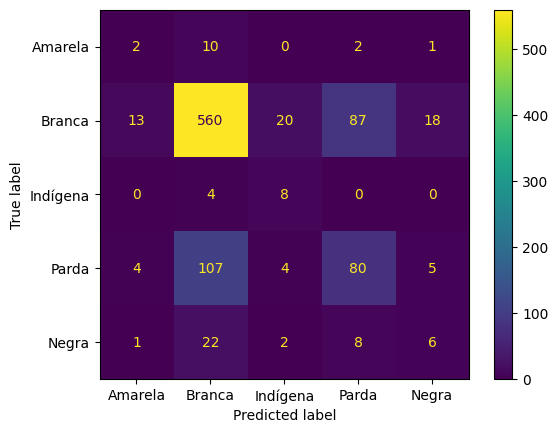

In [48]:
model_SVM.fit(X_train, y_train)
y_pred = model_SVM.predict(X_test)
evaluation_parametrics("Machine Learning - SVM", y_test, y_pred)

# Random Forest

In [49]:
model_Random_Forest = RandomForestClassifier(random_state=42, n_estimators=500, criterion="gini", max_features='sqrt', class_weight='balanced', n_jobs=-1, )
cross_val_results = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="accuracy")


print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.16915342 0.19977688 0.21286501 0.22033896 0.19741873]
Media da Accuracy:  0.7102448262044183
Media da MACRO F1:  0.1999105989732186
Desvio Padrão da MACRO F1:  0.017534915091334514


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.17      0.07      0.10        15
           1       0.76      0.92      0.83       698
           2       0.19      0.25      0.21        12
           3       0.56      0.23      0.32       200
           4       0.35      0.15      0.21        39

    accuracy                           0.73       964
   macro avg       0.41      0.32      0.34       964
weighted avg       0.69      0.73      0.68       964



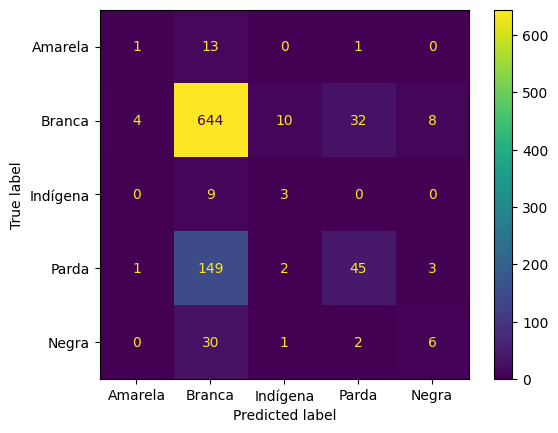

In [50]:
model_Random_Forest.fit(X_train, y_train)
y_pred = model_Random_Forest.predict(X_test)
evaluation_parametrics("Machine Learning - Random Forest", y_test, y_pred)

# Decision Tree

In [51]:
model_Decision_Tree = DecisionTreeClassifier(random_state=42, criterion="entropy", splitter="random", class_weight="balanced", ccp_alpha=0.0001)

cross_val_results = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.23574106 0.26765776 0.31601675 0.29818999 0.26037108]
Media da Accuracy:  0.5923712637289246
Media da MACRO F1:  0.2755953279174222
Desvio Padrão da MACRO F1:  0.028381528006790283


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.11      0.20      0.14        15
           1       0.77      0.78      0.78       698
           2       0.24      0.50      0.32        12
           3       0.36      0.30      0.33       200
           4       0.18      0.15      0.17        39

    accuracy                           0.65       964
   macro avg       0.33      0.39      0.35       964
weighted avg       0.64      0.65      0.64       964



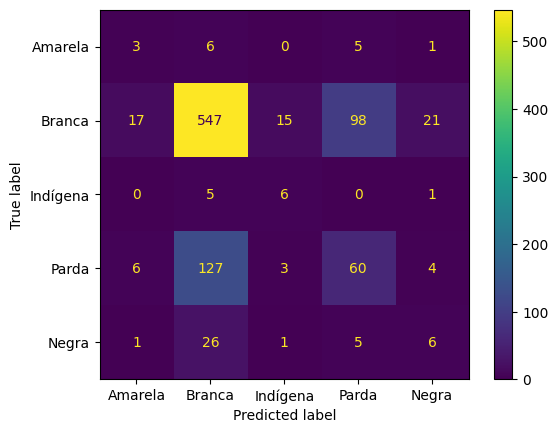

In [52]:
model_Decision_Tree.fit(X_train, y_train)
y_pred = model_Decision_Tree.predict(X_test)
evaluation_parametrics("Machine Learning - Decision Tree", y_test, y_pred)

In [70]:
## Funçao para Avaliação dos Modelos
# Refazer essa parte 
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

amarelos:int = df["cor"].loc[(df["cor"] == 0)].value_counts()
prob_amarelos = (int(amarelos)/len(df["cor"]))

branca:int = df["cor"].loc[(df["cor"] == 1)].value_counts()
prob_brancos = (int(branca)/len(df["cor"]))

indigena:int = df["cor"].loc[(df["cor"] == 2)].value_counts()
prob_indigena = (int(indigena)/len(df["cor"]))

pardos:int = df["cor"].loc[(df["cor"] == 3)].value_counts()
prob_pardos = (int(pardos)/len(df["cor"]))

pretos:int = df["cor"].loc[(df["cor"] == 4)].value_counts()
prob_pretos = (int(pretos)/len(df["cor"]))




resultado_sem_vies_accuracy = []
resultado_sem_vies_f1_score = []

rng_options = [8, 32, 42, 64, 128]

for _ in range(5):
    sem_vies = []
    rng = np.random.default_rng(rng_options[_])
    numbers = rng.random(len(y_test))

    for i in numbers:

        if i < prob_brancos:
            aux = y_train.loc[y_train == 1].sample(1)

        elif i > prob_brancos and i < prob_brancos + prob_pardos:
            aux = y_train.loc[y_train == 3].sample(1)

        elif i > prob_brancos + prob_pardos and i < prob_brancos + prob_pardos + prob_pretos:
            aux = y_train.loc[y_train == 4].sample(1)

        elif i > prob_brancos + prob_pardos + prob_pretos  and i < prob_brancos + prob_pardos + prob_pretos + prob_amarelos:
            aux = y_train.loc[y_train == 0].sample(1)

        elif i > prob_brancos + prob_pardos + prob_pretos + prob_amarelos:
            aux = y_train.loc[y_train == 2].sample(1)


        sem_vies.append(aux)
    # balanceamento = [df.loc[df["cor"] == 0].sample(1)  if i < prob_brancos else df.loc[df['cor'] == 1].sample(1) for i in numbers]

    new_df = pd.concat(sem_vies)
    resultado_sem_vies_accuracy.append(accuracy_score(y_test, new_df))
    resultado_sem_vies_f1_score.append(f1_score(y_test, new_df, average='macro'))


In [97]:
resultado_sem_vies_accuracy

[0.5726141078838174,
 0.5342323651452282,
 0.549792531120332,
 0.5518672199170125,
 0.5560165975103735]

In [71]:
print(f' Média da Acurácia: {sum(resultado_sem_vies_accuracy)/len(resultado_sem_vies_accuracy)}')
print(f' Média da Macro F1: {sum(resultado_sem_vies_f1_score)/len(resultado_sem_vies_f1_score)}')

 Média da Acurácia: 0.5529045643153527
 Média da Macro F1: 0.18833079435921735


# Aleatório

In [55]:
df['cor'].value_counts()

cor
1    3421
3     988
4     220
0     103
2      86
Name: count, dtype: int64

In [104]:
resultado_sem_vies_accuracy = []
resultado_sem_vies_f1_score = []
rng_options = [8, 32, 42, 64, 128]

for _ in range(5):
    sem_vies = []
    rng = np.random.default_rng(rng_options[_])
    numbers = rng.random(len(y_test))
    y_test1 = y_test[:960]

    for i in range(int((len(numbers))/5)):
        sem_vies.append(y_train.loc[y_train == 0].sample(1))
        sem_vies.append(y_train.loc[y_train == 1].sample(1))
        sem_vies.append(y_train.loc[y_train == 2].sample(1))
        sem_vies.append(y_train.loc[y_train == 3].sample(1))
        sem_vies.append(y_train.loc[y_train == 4].sample(1))

    new_df = pd.concat(sem_vies)
    resultado_sem_vies_accuracy.append(accuracy_score(y_test1, new_df))
    resultado_sem_vies_f1_score.append(f1_score(y_test1, new_df, average='macro'))


In [105]:
resultado_sem_vies_f1_score

[0.13045167316267062,
 0.13045167316267062,
 0.13045167316267062,
 0.13045167316267062,
 0.13045167316267062]